In [1]:

import math, random, time, copy, warnings, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import kagglehub
warnings.filterwarnings("ignore")

SEED = 42
# Keep experiments reproducible across NumPy, PyTorch, and Python random.
def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
# Initialize global seed
set_all_seeds(SEED)

# Use GPU when available; otherwise fall back to CPU.
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


In [2]:
# =========================
# Experiment settings
# =========================
# Each tuple is (input window length, prediction horizon).
experiment_settings = [
    (12, 3),
    (24, 3),
    (24, 6),
    (48, 6),
    (24, 12),
    (48, 12),
]

# =========================
# Training settings
# =========================
BATCH_SIZE = 128
EPOCHS = 120
PATIENCE = 8
LR = 5e-4
WEIGHT_DECAY = 1e-5
HUBER_DELTA = 0.01
CLIP_VAL = 5.0

# =========================
# LSTM settings
# =========================
LSTM_HIDDEN = 96
LSTM_LAYERS = 2
LSTM_DROPOUT = 0.1

# =========================
# Transformer settings
# =========================
TRANS_D_MODEL = 64
TRANS_NHEAD = 4
TRANS_LAYERS = 2
TRANS_FF = 128
TRANS_DROPOUT = 0.1

# =========================
# Split ratios
# =========================
TRAIN_RATIO = 0.80
VAL_RATIO = 0.10

print("experiment_settings =", experiment_settings)

experiment_settings = [(12, 3), (24, 3), (24, 6), (48, 6), (24, 12), (48, 12)]


In [3]:
# Download the hourly BTC OHCLV dataset from Kaggle Hub if needed.
DATA_DIR = kagglehub.dataset_download("mouadjaouhari/bitcoin-hourly-ohclv-dataset")
print("Dataset directory:", DATA_DIR)

csv_files = [f for f in os.listdir(DATA_DIR) if f.lower().endswith(".csv")]
if not csv_files:
    raise FileNotFoundError(f"No CSV file found in {DATA_DIR}")

print("CSV files found:", csv_files)

DATA_PATH = os.path.join(DATA_DIR, csv_files[0])
print("Using file:", DATA_PATH)

df = pd.read_csv(DATA_PATH)
df.columns = [c.upper() for c in df.columns]

required_cols = ["DATETIME", "OPEN", "HIGH", "LOW", "CLOSE", "VOLUME"]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing columns: {missing_cols}\nFound columns: {df.columns.tolist()}")

# Sort chronologically because this is a time-series forecasting task.
df["DATETIME"] = pd.to_datetime(df["DATETIME"])
df = df.sort_values("DATETIME").drop_duplicates("DATETIME").reset_index(drop=True)

# Restrict to 2015-2025
start_date = "2015-01-01"
end_date = "2025-01-01"
df = df[(df["DATETIME"] >= start_date) & (df["DATETIME"] <= end_date)].copy()
df = df.reset_index(drop=True)

# Fill missing price/volume values conservatively with nearby observations.
price_cols = ["OPEN", "HIGH", "LOW", "CLOSE", "VOLUME"]
df[price_cols] = (
    df[price_cols]
    .replace([np.inf, -np.inf], np.nan)
    .ffill()
    .bfill()
)

print("Loaded dataframe shape:", df.shape)
print("Min DATETIME:", df["DATETIME"].min())
print("Max DATETIME:", df["DATETIME"].max())

display(df.head(3))
display(df.tail(3))

Dataset directory: C:\Users\12673\.cache\kagglehub\datasets\mouadjaouhari\bitcoin-hourly-ohclv-dataset\versions\10
CSV files found: ['btc_hourly_ohclv_ta.csv']
Using file: C:\Users\12673\.cache\kagglehub\datasets\mouadjaouhari\bitcoin-hourly-ohclv-dataset\versions\10\btc_hourly_ohclv_ta.csv
Loaded dataframe shape: (87673, 28)
Min DATETIME: 2015-01-01 00:00:00
Max DATETIME: 2025-01-01 00:00:00


,UNIX_TIMESTAMP,DATETIME,OPEN,HIGH,CLOSE,LOW,VOLUME,SMA_20,EMA_12,EMA_26,...,STOCH_D,VOLUME_SMA,MFI,ATR,PRICE_CHANGE,HIGH_LOW_RATIO,CLOSE_OPEN_RATIO,VOLATILITY_30D,PRICE_VOLATILITY_30D,HL_VOLATILITY_30D
0,1420070400,2015-01-01 00:00:00,318.78,321.31,319.33,317.41,412155.35,314.4475,316.391397,314.745154,...,90.140614,297896.5065,65.627586,2.495835,0.001725,1.012287,1.001725,0.036481,23.343829,0.008373
1,1420074000,2015-01-01 01:00:00,319.33,319.63,317.54,316.88,231354.12,314.7640,316.568105,314.952180,...,83.500900,302135.7575,65.320811,2.513990,-0.005605,1.008678,0.994395,0.036492,23.317641,0.008378
2,1420077600,2015-01-01 02:00:00,317.54,319.06,317.40,316.45,159463.15,315.0895,316.696089,315.133500,...,76.059480,300717.4440,67.182849,2.520848,-0.000441,1.008248,0.999559,0.036490,23.293209,0.008380


,UNIX_TIMESTAMP,DATETIME,OPEN,HIGH,CLOSE,LOW,VOLUME,SMA_20,EMA_12,EMA_26,...,STOCH_D,VOLUME_SMA,MFI,ATR,PRICE_CHANGE,HIGH_LOW_RATIO,CLOSE_OPEN_RATIO,VOLATILITY_30D,PRICE_VOLATILITY_30D,HL_VOLATILITY_30D
87670,1735682400,2024-12-31 22:00:00,93724.89,93726.50,93308.18,93217.49,6.555135e+07,93797.7550,93886.853528,93755.194395,...,19.812719,1.546700e+08,45.301401,773.716554,-0.004446,1.005460,0.995554,0.029267,3539.714398,0.008044
87671,1735686000,2024-12-31 23:00:00,93308.18,93585.25,93391.98,93215.57,1.102438e+08,93849.2740,93810.719139,93728.289625,...,16.293817,1.556217e+08,42.696884,744.856800,0.000898,1.003966,1.000898,0.029261,3544.332951,0.008041
87672,1735689600,2025-01-01 00:00:00,93391.98,94297.00,94203.42,93294.16,1.170988e+08,93943.8465,93871.134656,93763.484468,...,18.921706,1.590980e+08,43.938214,763.284172,0.008689,1.010749,1.008689,0.029301,3547.579468,0.008048


In [4]:

def engineer_features_volatility(df, horizon=6):
    # Work on a copy so the raw dataframe stays unchanged.
    df = df.copy()

    # Basic log price and 1-hour return
    df["LOG_CLOSE"] = np.log(df["CLOSE"])
    df["RET_1H"] = df["LOG_CLOSE"].diff()

    # Dynamic forecasting target
    target_col = f"TARGET_RV_{horizon}H"
    rv_feature_col = f"RV_{horizon}H"
    df[target_col] = df["RET_1H"].rolling(horizon).std().shift(-horizon)

    # Basic market features
    df["LOG_VOLUME"] = np.log1p(df["VOLUME"])
    df["HL_SPREAD"] = (df["HIGH"] - df["LOW"]) / (df["CLOSE"] + 1e-8)
    df["CO_RETURN"] = np.log((df["CLOSE"] + 1e-8) / (df["OPEN"] + 1e-8))
    df["VOL_RATIO_24"] = df["VOLUME"] / (df["VOLUME"].rolling(24).mean() + 1e-8)

    ret_windows = sorted(set([6, 12, 24, 48, 72]))
    rv_windows = sorted(set([6, 12, 24, horizon]))

    # Build multi-scale return and realized-volatility features.
    for w in ret_windows:
        df[f"RET_MEAN_{w}"] = df["RET_1H"].rolling(w).mean()
        df[f"RET_STD_{w}"] = df["RET_1H"].rolling(w).std()

    for w in rv_windows:
        df[f"RV_{w}H"] = df["RET_1H"].rolling(w).std()

    # Add a few standard technical indicators as volatility proxies.
    delta = df["CLOSE"].diff()
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = (-delta.clip(upper=0)).rolling(14).mean()
    df["RSI_14"] = 100 - 100 / (1 + gain / (loss + 1e-8))

    sma20 = df["CLOSE"].rolling(20).mean()
    std20 = df["CLOSE"].rolling(20).std()
    df["BB_WIDTH"] = (4 * std20) / (sma20 + 1e-8)

    prev_close = df["CLOSE"].shift(1)
    true_range = pd.concat([
        df["HIGH"] - df["LOW"],
        (df["HIGH"] - prev_close).abs(),
        (df["LOW"] - prev_close).abs()
    ], axis=1).max(axis=1)
    df["ATR_PCT"] = true_range.rolling(14).mean() / (df["CLOSE"] + 1e-8)

    ema12 = df["CLOSE"].ewm(span=12, adjust=False).mean()
    ema26 = df["CLOSE"].ewm(span=26, adjust=False).mean()
    macd = ema12 - ema26
    macd_signal = macd.ewm(span=9, adjust=False).mean()

    df["EMA12_DEV"] = (df["CLOSE"] - ema12) / (ema12 + 1e-8)
    df["EMA26_DEV"] = (df["CLOSE"] - ema26) / (ema26 + 1e-8)
    df["MACD_PCT"] = macd / (df["CLOSE"] + 1e-8)
    df["MACD_SIGNAL_PCT"] = macd_signal / (df["CLOSE"] + 1e-8)
    df["MACD_HIST_PCT"] = (macd - macd_signal) / (df["CLOSE"] + 1e-8)

    df["HOUR"] = df["DATETIME"].dt.hour
    df["DOW"] = df["DATETIME"].dt.dayofweek
    df["IS_WEEKEND"] = (df["DOW"] >= 5).astype(float)
    df["HOUR_SIN"] = np.sin(2 * np.pi * df["HOUR"] / 24.0)
    df["HOUR_COS"] = np.cos(2 * np.pi * df["HOUR"] / 24.0)
    df["DOW_SIN"] = np.sin(2 * np.pi * df["DOW"] / 7.0)
    df["DOW_COS"] = np.cos(2 * np.pi * df["DOW"] / 7.0)

    # Final feature list used by all models in this experiment.
    feature_cols = [
        "OPEN", "HIGH", "LOW", "CLOSE", "VOLUME",
        "RET_1H", "LOG_VOLUME", "HL_SPREAD", "CO_RETURN", "VOL_RATIO_24",
        "RSI_14", "BB_WIDTH", "ATR_PCT",
        "EMA12_DEV", "EMA26_DEV", "MACD_PCT", "MACD_SIGNAL_PCT", "MACD_HIST_PCT",
        "HOUR_SIN", "HOUR_COS", "DOW_SIN", "DOW_COS", "IS_WEEKEND",
    ] + [f"RV_{w}H" for w in rv_windows] + [f"RET_MEAN_{w}" for w in ret_windows] + [f"RET_STD_{w}" for w in ret_windows]

    # Shift all inputs by one step to avoid leaking current-bar information.
    for col in feature_cols:
        df[col] = df[col].shift(1)

    df = df.dropna().reset_index(drop=True)
    return df, feature_cols, target_col, rv_feature_col


In [5]:

class BTCVolatilityDataset(Dataset):
    # Each sample is a rolling window, and the target is aligned with its last step.
    def __init__(self, X, y, window=24):
        self.X = torch.as_tensor(X, dtype=torch.float32)
        self.y = torch.as_tensor(y, dtype=torch.float32)
        self.window = window
        if len(self.X) < self.window:
            raise ValueError(f"Window size {self.window} is larger than dataset length {len(self.X)}")

    def __len__(self):
        return len(self.X) - self.window + 1

    def __getitem__(self, idx):
        x_win = self.X[idx: idx + self.window]
        y_out = self.y[idx + self.window - 1]
        return x_win, y_out


class NaiveVolatilityModel(nn.Module):
    # Baseline: predict with the last observed realized volatility feature.
    def __init__(self, rv_index):
        super().__init__()
        self.rv_index = rv_index

    def forward(self, x):
        return x[:, -1, self.rv_index]


class LSTMRegressor(nn.Module):
    # Sequence model that summarizes the rolling window with stacked LSTM layers.
    def __init__(self, input_dim, hidden_dim=96, num_layers=2, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :]).squeeze(1)


class PositionalEncoding(nn.Module):
    # Standard sinusoidal positional encoding for Transformer inputs.
    def __init__(self, d_model, max_len=512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div[:pe[:, 1::2].shape[1]])
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]


class Time2Vec(nn.Module):
    # Learnable temporal embedding with one linear term and periodic terms.
    def __init__(self, d_model):
        super().__init__()
        self.w0 = nn.Parameter(0.1 * torch.randn(1))
        self.b0 = nn.Parameter(torch.zeros(1))
        self.w = nn.Parameter(0.1 * torch.randn(d_model - 1))
        self.b = nn.Parameter(torch.zeros(d_model - 1))

    def forward(self, seq_len, device):
        t = torch.arange(seq_len, device=device).float().unsqueeze(1)
        v0 = self.w0 * t + self.b0
        vp = torch.sin(t * self.w.unsqueeze(0) + self.b.unsqueeze(0))
        return torch.cat([v0, vp], dim=1).unsqueeze(0)


class TransformerRegressor(nn.Module):
    def __init__(self, input_dim, d_model=64, nhead=4, num_layers=2, ff_dim=128, dropout=0.1, use_time2vec=False):
        super().__init__()
        self.use_time2vec = use_time2vec
        self.input_proj = nn.Linear(input_dim, d_model)

        if use_time2vec:
            self.time_embed = Time2Vec(d_model)
        else:
            self.pos_encoder = PositionalEncoding(d_model, max_len=512)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=ff_dim,
            dropout=dropout,
            batch_first=True,
            activation="gelu"
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, 1)
        )

    def forward(self, x):
        # Encode the sequence and predict the next volatility from the last token.
        x = self.input_proj(x)
        if self.use_time2vec:
            x = x + self.time_embed(x.size(1), x.device)
        else:
            x = self.pos_encoder(x)
        x = self.encoder(x)
        return self.head(x[:, -1, :]).squeeze(1)


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def regression_metrics(y_true, y_pred):
    # Report a compact set of metrics for easy model comparison.
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    if len(y_true) > 1 and np.std(y_true) > 1e-12 and np.std(y_pred) > 1e-12:
        corr = np.corrcoef(y_true, y_pred)[0, 1]
    else:
        corr = np.nan
    return {"MAE": mae, "RMSE": rmse, "R2": r2, "Corr": corr}


def evaluate_model(model, loader, criterion, device):
    # Run one full pass without gradients and collect predictions.
    model.eval()
    total_loss = 0.0
    preds_all, tgts_all = [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            preds = model(x)
            loss = criterion(preds, y)
            total_loss += loss.item() * len(y)
            preds_all.append(preds.cpu().numpy())
            tgts_all.append(y.cpu().numpy())
    preds_all = np.concatenate(preds_all)
    tgts_all = np.concatenate(tgts_all)
    metrics = regression_metrics(tgts_all, preds_all)
    return total_loss / len(loader.dataset), preds_all, tgts_all, metrics


def train_model(model, train_loader, val_loader, model_name,
                lr=5e-4, weight_decay=1e-5, epochs=30, patience=8,
                delta=0.01, device=DEVICE):
    model = model.to(device)
    # Huber loss is more robust than MSE when volatility spikes create outliers.
    criterion = nn.HuberLoss(delta=delta)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

    best_val_loss = np.inf
    best_state = None
    history = {"train_loss": [], "val_loss": [], "val_mae": [], "val_rmse": [], "val_corr": []}
    wait = 0
    t0 = time.time()

    print(f"\n=== {model_name} ({count_params(model):,} params) ===")

    for epoch in range(1, epochs + 1):
        model.train()
        running = 0.0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            preds = model(x)
            loss = criterion(preds, y)
            loss.backward()
            # Gradient clipping helps stabilize training on noisy sequences.
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            running += loss.item() * len(y)

        train_loss = running / len(train_loader.dataset)
        val_loss, _, _, val_metrics = evaluate_model(model, val_loader, criterion, device)
        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_mae"].append(val_metrics["MAE"])
        history["val_rmse"].append(val_metrics["RMSE"])
        history["val_corr"].append(val_metrics["Corr"])

        if epoch == 1 or epoch % 5 == 0:
            print(
                f"Epoch {epoch:>3}/{epochs} | "
                f"Train Huber {train_loss:.6f} | "
                f"Val Huber {val_loss:.6f} | "
                f"Val MAE {val_metrics['MAE']:.6f} | "
                f"Val RMSE {val_metrics['RMSE']:.6f} | "
                f"Val Corr {val_metrics['Corr']:.4f} | "
                f"lr {optimizer.param_groups[0]['lr']:.1e}"
            )

        # Keep the best checkpoint based on validation Huber loss.
        if val_loss < best_val_loss - 1e-6:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    print(f"Best val Huber = {best_val_loss:.6f}")
    print(f"{model_name} finished in {(time.time() - t0) / 60.0:.2f} minutes")
    return model, history


def run_final_eval(model, loader, model_name, device=DEVICE):
    criterion = nn.HuberLoss(delta=HUBER_DELTA)
    loss, preds, tgts, metrics = evaluate_model(model, loader, criterion, device)
    return {
        "model": model_name,
        "HuberLoss": loss,
        "MAE": metrics["MAE"],
        "RMSE": metrics["RMSE"],
        "R2": metrics["R2"],
        "Corr": metrics["Corr"],
        "Params": count_params(model)
    }, preds, tgts


In [6]:
def run_experiment(df_raw, window_len, horizon, seed=None, verbose=True, plot_example=True):
    # Full pipeline for one (window, horizon, seed) configuration.
    if seed is not None:
        set_all_seeds(seed)
    if verbose:
        print("\n" + "=" * 80)
        print(f"Running experiment with WINDOW_LEN={window_len}, HORIZON={horizon}, SEED={seed}")
        print("=" * 80)

    df_feat, feature_cols, target_col, rv_feature_col = engineer_features_volatility(df_raw, horizon=horizon)

    # Split chronologically so future observations never leak backward.
    n = len(df_feat)
    train_end = int(n * TRAIN_RATIO)
    val_end = int(n * (TRAIN_RATIO + VAL_RATIO))

    train_df = df_feat.iloc[:train_end].copy()
    val_df = df_feat.iloc[train_end:val_end].copy()
    test_df = df_feat.iloc[val_end:].copy()

    if verbose:
        for name, d in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
            print(f"{name:5s}: {len(d):>6,} rows | {d['DATETIME'].min()} -> {d['DATETIME'].max()}")
            print(f"   target mean = {d[target_col].mean():.6f}")
            print(f"   target std  = {d[target_col].std():.6f}")

    # Fit the scaler on the training split only, then reuse it for val/test.
    x_scaler = RobustScaler()
    train_X = x_scaler.fit_transform(train_df[feature_cols])
    val_X = x_scaler.transform(val_df[feature_cols])
    test_X = x_scaler.transform(test_df[feature_cols])

    # Clip extreme scaled values to reduce the effect of large outliers.
    train_X = np.clip(train_X, -CLIP_VAL, CLIP_VAL).astype(np.float32)
    val_X = np.clip(val_X, -CLIP_VAL, CLIP_VAL).astype(np.float32)
    test_X = np.clip(test_X, -CLIP_VAL, CLIP_VAL).astype(np.float32)

    train_y = train_df[target_col].to_numpy(dtype=np.float32)
    val_y = val_df[target_col].to_numpy(dtype=np.float32)
    test_y = test_df[target_col].to_numpy(dtype=np.float32)

    # Convert each chronological split into rolling-window samples.
    train_ds = BTCVolatilityDataset(train_X, train_y, window=window_len)
    val_ds = BTCVolatilityDataset(val_X, val_y, window=window_len)
    test_ds = BTCVolatilityDataset(test_X, test_y, window=window_len)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

    # Locate the horizon-matched RV feature used by the naive baseline.
    input_dim = len(feature_cols)
    rv_index = feature_cols.index(rv_feature_col)

    naive_model = NaiveVolatilityModel(rv_index)
    lstm_model = LSTMRegressor(
        input_dim=input_dim,
        hidden_dim=LSTM_HIDDEN,
        num_layers=LSTM_LAYERS,
        dropout=LSTM_DROPOUT
    )
    transformer_sin = TransformerRegressor(
        input_dim=input_dim,
        d_model=TRANS_D_MODEL,
        nhead=TRANS_NHEAD,
        num_layers=TRANS_LAYERS,
        ff_dim=TRANS_FF,
        dropout=TRANS_DROPOUT,
        use_time2vec=False
    )
    transformer_t2v = TransformerRegressor(
        input_dim=input_dim,
        d_model=TRANS_D_MODEL,
        nhead=TRANS_NHEAD,
        num_layers=TRANS_LAYERS,
        ff_dim=TRANS_FF,
        dropout=TRANS_DROPOUT,
        use_time2vec=True
    )

    if verbose:
        print("Naive params             =", count_params(naive_model))
        print("LSTM params              =", count_params(lstm_model))
        print("Transformer-SinPE params =", count_params(transformer_sin))
        print("Transformer-T2V params   =", count_params(transformer_t2v))

    lstm_model, hist_lstm = train_model(
        lstm_model, train_loader, val_loader,
        f"LSTM-RV{horizon}H-W{window_len}",
        lr=LR, weight_decay=WEIGHT_DECAY, epochs=EPOCHS,
        patience=PATIENCE, delta=HUBER_DELTA
    )
    transformer_sin, hist_sin = train_model(
        transformer_sin, train_loader, val_loader,
        f"Transformer-SinPE-RV{horizon}H-W{window_len}",
        lr=LR, weight_decay=WEIGHT_DECAY, epochs=EPOCHS,
        patience=PATIENCE, delta=HUBER_DELTA
    )
    transformer_t2v, hist_t2v = train_model(
        transformer_t2v, train_loader, val_loader,
        f"Transformer-Time2Vec-RV{horizon}H-W{window_len}",
        lr=LR, weight_decay=WEIGHT_DECAY, epochs=EPOCHS,
        patience=PATIENCE, delta=HUBER_DELTA
    )

    # Evaluate the naive baseline by carrying forward the last observed RV feature.
    # Validation results
    naive_val_pred = np.array([
        val_df[rv_feature_col].iloc[i + window_len - 1]
        for i in range(len(val_df) - window_len + 1)
    ], dtype=np.float32)
    naive_val_true = np.array([
        val_df[target_col].iloc[i + window_len - 1]
        for i in range(len(val_df) - window_len + 1)
    ], dtype=np.float32)
    naive_val_metrics = regression_metrics(naive_val_true, naive_val_pred)
    naive_val_huber = nn.HuberLoss(delta=HUBER_DELTA)(
        torch.tensor(naive_val_pred), torch.tensor(naive_val_true)
    ).item()

    val_rows = [{
        "model": f"Naive-RV{horizon}H",
        "HuberLoss": naive_val_huber,
        "MAE": naive_val_metrics["MAE"],
        "RMSE": naive_val_metrics["RMSE"],
        "R2": naive_val_metrics["R2"],
        "Corr": naive_val_metrics["Corr"],
        "Params": 0
    }]
    for model, name in [
        (lstm_model, f"LSTM-RV{horizon}H"),
        (transformer_sin, f"Transformer-SinPE-RV{horizon}H"),
        (transformer_t2v, f"Transformer-Time2Vec-RV{horizon}H")
    ]:
        row, _, _ = run_final_eval(model, val_loader, name)
        val_rows.append(row)
    val_results = pd.DataFrame(val_rows).sort_values("RMSE").reset_index(drop=True)
    val_results["WINDOW_LEN"] = window_len
    val_results["HORIZON"] = horizon
    val_results["Split"] = "Validation"

    # Test results
    naive_test_pred = np.array([
        test_df[rv_feature_col].iloc[i + window_len - 1]
        for i in range(len(test_df) - window_len + 1)
    ], dtype=np.float32)
    naive_test_true = np.array([
        test_df[target_col].iloc[i + window_len - 1]
        for i in range(len(test_df) - window_len + 1)
    ], dtype=np.float32)
    naive_test_metrics = regression_metrics(naive_test_true, naive_test_pred)
    naive_test_huber = nn.HuberLoss(delta=HUBER_DELTA)(
        torch.tensor(naive_test_pred), torch.tensor(naive_test_true)
    ).item()

    test_rows = [{
        "model": f"Naive-RV{horizon}H",
        "HuberLoss": naive_test_huber,
        "MAE": naive_test_metrics["MAE"],
        "RMSE": naive_test_metrics["RMSE"],
        "R2": naive_test_metrics["R2"],
        "Corr": naive_test_metrics["Corr"],
        "Params": 0
    }]

    # Cache predictions so later cells can plot and compare models.
    test_pred_cache = {"Naive": (naive_test_true, naive_test_pred)}
    for model, name, short_name in [
        (lstm_model, f"LSTM-RV{horizon}H", "LSTM"),
        (transformer_sin, f"Transformer-SinPE-RV{horizon}H", "Transformer-SinPE"),
        (transformer_t2v, f"Transformer-Time2Vec-RV{horizon}H", "Transformer-Time2Vec")
    ]:
        row, preds, tgts = run_final_eval(model, test_loader, name)
        test_rows.append(row)
        test_pred_cache[short_name] = (tgts, preds)

    test_results = pd.DataFrame(test_rows).sort_values("RMSE").reset_index(drop=True)
    test_results["WINDOW_LEN"] = window_len
    test_results["HORIZON"] = horizon
    test_results["Split"] = "Test"

    if verbose:
        print("\nValidation results")
        display(val_results)
        print("\nTest results")
        display(test_results)

    if plot_example:
        example_model = "Transformer-Time2Vec"
        true_y, pred_y = test_pred_cache[example_model]
        plot_n = min(100, len(true_y))
        plt.figure(figsize=(14, 4))
        plt.plot(true_y[:plot_n], label="Actual", linewidth=2)
        plt.plot(pred_y[:plot_n], label=example_model, alpha=0.8)
        plt.title(f"Test Set: Actual vs {example_model} | WINDOW_LEN={window_len}, HORIZON={horizon}")
        plt.xlabel("Sample Index")
        plt.ylabel("Realized Volatility")
        plt.legend()
        plt.show()

    # Per-model files are no longer written to disk.
    # The notebook now relies on the experiment cache created in Cell 6.

    return {
        "val_results": val_results,
        "test_results": test_results,
        "histories": {
            "LSTM": hist_lstm,
            "Transformer-SinPE": hist_sin,
            "Transformer-Time2Vec": hist_t2v,
        },
        "predictions": test_pred_cache,
        "meta": {
            "window_len": window_len,
            "horizon": horizon,
            "seed": seed,
            "target_col": target_col,
            "rv_feature_col": rv_feature_col,
            "num_features": len(feature_cols),
        }
    }

In [7]:

import pickle

cache_path = os.path.join("models", "experiment_cache.pkl")

if os.path.exists(cache_path):
    # Reuse cached experiment outputs so the full training loop does not need to run again.
    with open(cache_path, "rb") as f:
        cache = pickle.load(f)
    all_val_results = cache["all_val_results"]
    all_test_results = cache["all_test_results"]
    experiment_outputs = cache["experiment_outputs"]
    print(f"Loaded cached experiment results from {cache_path}")
else:
    all_val_results = []
    all_test_results = []
    experiment_outputs = {}

    # Repeat each (WINDOW_LEN, HORIZON) across multiple seeds.
    # This reduces the chance that one lucky initialization dominates the result.
    SEEDS = [SEED + i for i in range(5)]
    for s_idx, seed in enumerate(SEEDS):
        for idx, (window_len, horizon) in enumerate(experiment_settings):
            output = run_experiment(
                df_raw=df,
                window_len=window_len,
                horizon=horizon,
                seed=seed,
                verbose=True,
                plot_example=(s_idx == 0 and idx == 0)
            )
            # Keep every run keyed by seed/window/horizon for later analysis.
            key = f"S{seed}_W{window_len}_H{horizon}"
            experiment_outputs[key] = output
            all_val_results.append(output["val_results"].assign(SEED=seed))
            all_test_results.append(output["test_results"].assign(SEED=seed))

    all_val_results = pd.concat(all_val_results, ignore_index=True)
    all_test_results = pd.concat(all_test_results, ignore_index=True)

    os.makedirs("models", exist_ok=True)
    with open(cache_path, "wb") as f:
        pickle.dump({
            "all_val_results": all_val_results,
            "all_test_results": all_test_results,
            "experiment_outputs": experiment_outputs,
        }, f)
    print(f"Saved experiment cache to {cache_path}")

print("Combined validation results")
display(all_val_results.sort_values(["HORIZON", "WINDOW_LEN", "RMSE"]).reset_index(drop=True))

print("Combined test results")
display(all_test_results.sort_values(["HORIZON", "WINDOW_LEN", "RMSE"]).reset_index(drop=True))


Loaded cached experiment results from models\experiment_cache.pkl
Combined validation results


,model,HuberLoss,MAE,RMSE,R2,Corr,Params,WINDOW_LEN,HORIZON,Split,SEED
0,LSTM-RV3H,0.000004,0.001727,0.003078,0.101923,0.388593,135745,12,3,Validation,46
1,Transformer-Time2Vec-RV3H,0.000004,0.001798,0.003080,0.100904,0.345776,73729,12,3,Validation,45
2,Transformer-SinPE-RV3H,0.000004,0.001807,0.003082,0.099697,0.342121,73601,12,3,Validation,46
3,Transformer-Time2Vec-RV3H,0.000004,0.002113,0.003100,0.089129,0.349900,73729,12,3,Validation,42
4,Transformer-SinPE-RV3H,0.000004,0.002114,0.003106,0.085766,0.342363,73601,12,3,Validation,43
...,...,...,...,...,...,...,...,...,...,...,...
115,Naive-RV12H,0.000005,0.002043,0.003081,-0.421814,0.289221,0,48,12,Validation,42
116,Naive-RV12H,0.000005,0.002043,0.003081,-0.421814,0.289221,0,48,12,Validation,43
117,Naive-RV12H,0.000005,0.002043,0.003081,-0.421814,0.289221,0,48,12,Validation,44
118,Naive-RV12H,0.000005,0.002043,0.003081,-0.421814,0.289221,0,48,12,Validation,45


Combined test results


,model,HuberLoss,MAE,RMSE,R2,Corr,Params,WINDOW_LEN,HORIZON,Split,SEED
0,LSTM-RV3H,0.000005,0.002312,0.003424,0.142917,0.386535,135745,12,3,Test,44
1,Transformer-Time2Vec-RV3H,0.000006,0.002345,0.003471,0.119153,0.365434,73729,12,3,Test,44
2,Transformer-SinPE-RV3H,0.000006,0.002280,0.003484,0.112771,0.374900,73601,12,3,Test,46
3,Transformer-Time2Vec-RV3H,0.000006,0.002253,0.003540,0.083615,0.388958,73729,12,3,Test,43
4,Transformer-SinPE-RV3H,0.000006,0.002256,0.003555,0.075809,0.370888,73601,12,3,Test,44
...,...,...,...,...,...,...,...,...,...,...,...
115,LSTM-RV12H,0.000006,0.002399,0.003416,-0.486787,0.286989,135361,48,12,Test,45
116,Transformer-SinPE-RV12H,0.000006,0.002604,0.003506,-0.566620,0.513674,73537,48,12,Test,46
117,LSTM-RV12H,0.000007,0.002945,0.003774,-0.814550,0.503829,135361,48,12,Test,46
118,LSTM-RV12H,0.000008,0.003275,0.004007,-1.045977,0.544028,135361,48,12,Test,42


In [8]:
summary_test = all_test_results.copy()
# Aggregate repeated runs into mean/std summaries for each setting.
summary_test["BaseModel"] = summary_test["model"].str.replace(r"-RV\d+H", "", regex=True)
summary_test = summary_test[["WINDOW_LEN", "HORIZON", "BaseModel", "MAE", "RMSE", "R2", "Corr", "HuberLoss", "SEED"]]

# Group by (WINDOW_LEN, HORIZON, BaseModel) and compute mean ± std across seeds
metrics = ["MAE", "RMSE", "R2", "Corr", "HuberLoss"]

# Format the results as "mean ± std"
result_rows = []
for (w, h, m), group_data in summary_test.groupby(["WINDOW_LEN", "HORIZON", "BaseModel"]):
    row = {
        "WINDOW_LEN": w,
        "HORIZON": h,
        "Model": m,
    }
    for metric in metrics:
        mean_val = group_data[metric].mean()
        std_val = group_data[metric].std()
        row[metric] = f"{mean_val:.6f} ± {std_val:.6f}"
    result_rows.append(row)

summary_mean_std = pd.DataFrame(result_rows).sort_values(["HORIZON", "WINDOW_LEN", "Model"]).reset_index(drop=True)

# Display results with clear title
print("\n" + "="*100)
print("FINAL RESULTS: mean ± std across 5 seeds")
print("="*100 + "\n")
display(summary_mean_std)


FINAL RESULTS: mean ± std across 5 seeds



,WINDOW_LEN,HORIZON,Model,MAE,RMSE,R2,Corr,HuberLoss
0,12,3,LSTM,0.002465 ± 0.000150,0.003795 ± 0.000239,-0.056206 ± 0.129825,0.385948 ± 0.017075,0.000007 ± 0.000001
1,12,3,Naive,0.003084 ± 0.000000,0.004561 ± 0.000000,-0.520691 ± 0.000000,0.239676 ± 0.000000,0.000010 ± 0.000000
2,12,3,Transformer-SinPE,0.002611 ± 0.000342,0.003718 ± 0.000227,-0.013561 ± 0.125214,0.361220 ± 0.032061,0.000007 ± 0.000001
3,12,3,Transformer-Time2Vec,0.002404 ± 0.000262,0.003564 ± 0.000065,0.071053 ± 0.033989,0.374207 ± 0.009849,0.000006 ± 0.000000
4,24,3,LSTM,0.002638 ± 0.000283,0.004020 ± 0.000308,-0.185990 ± 0.186486,0.372052 ± 0.027822,0.000008 ± 0.000001
5,24,3,Naive,0.003085 ± 0.000000,0.004562 ± 0.000000,-0.520703 ± 0.000000,0.239661 ± 0.000000,0.000010 ± 0.000000
6,24,3,Transformer-SinPE,0.002363 ± 0.000129,0.003529 ± 0.000088,0.089745 ± 0.045474,0.372322 ± 0.020828,0.000006 ± 0.000000
7,24,3,Transformer-Time2Vec,0.002403 ± 0.000116,0.003550 ± 0.000094,0.078662 ± 0.048803,0.376824 ± 0.025307,0.000006 ± 0.000000
8,24,6,LSTM,0.002614 ± 0.000558,0.003717 ± 0.000486,-0.369598 ± 0.363672,0.457777 ± 0.052842,0.000007 ± 0.000002
9,24,6,Naive,0.002598 ± 0.000000,0.003679 ± 0.000000,-0.323862 ± 0.000000,0.338092 ± 0.000000,0.000007 ± 0.000000


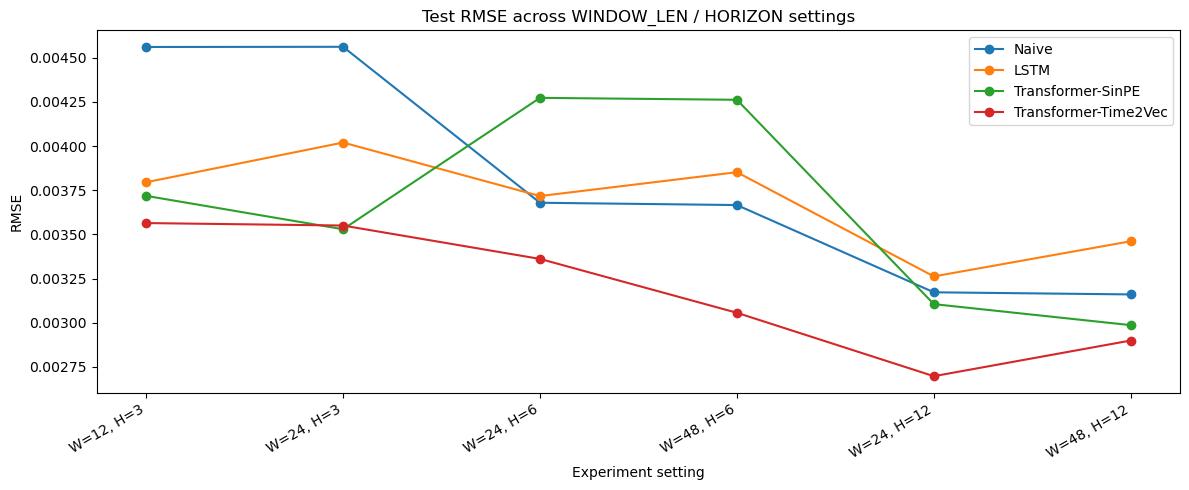

In [9]:

# Extract RMSE values from summary_mean_std (format: "mean ± std")
# Extract RMSE means so the aggregated table can be plotted numerically.
plot_df = summary_mean_std.copy()
plot_df["RMSE_mean"] = plot_df["RMSE"].str.split(" ").str[0].astype(float)
plot_df["Setting"] = plot_df.apply(lambda r: f"W={int(r['WINDOW_LEN'])}, H={int(r['HORIZON'])}", axis=1)
model_order = ["Naive", "LSTM", "Transformer-SinPE", "Transformer-Time2Vec"]

plt.figure(figsize=(12, 5))
for model_name in model_order:
    sub = plot_df[plot_df["Model"] == model_name]
    plt.plot(sub["Setting"], sub["RMSE_mean"], marker="o", label=model_name)

plt.title("Test RMSE across WINDOW_LEN / HORIZON settings")
plt.xlabel("Experiment setting")
plt.ylabel("RMSE")
plt.xticks(rotation=30, ha="right")
plt.legend()
plt.tight_layout()
plt.show()


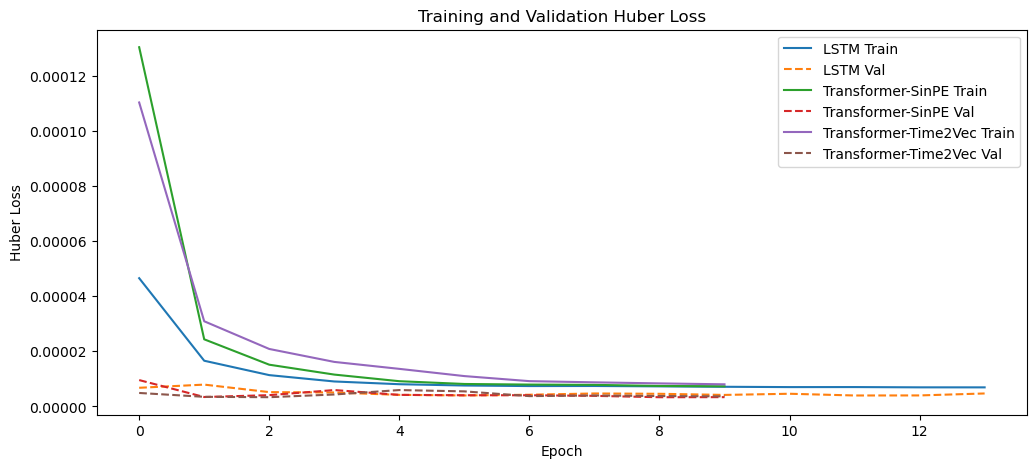

In [10]:
# Pick one saved run as a representative example for diagnostic plots.
example_key = "S42_W24_H6"
example_output = experiment_outputs[example_key]
histories = example_output["histories"]

plt.figure(figsize=(12, 5))

for model_name, hist in histories.items():
    # Solid lines show training loss and dashed lines show validation loss.
    plt.plot(hist["train_loss"], label=f"{model_name} Train")
    plt.plot(hist["val_loss"], linestyle="--", label=f"{model_name} Val")

plt.title("Training and Validation Huber Loss")
plt.xlabel("Epoch")
plt.ylabel("Huber Loss")
plt.legend()
plt.show()

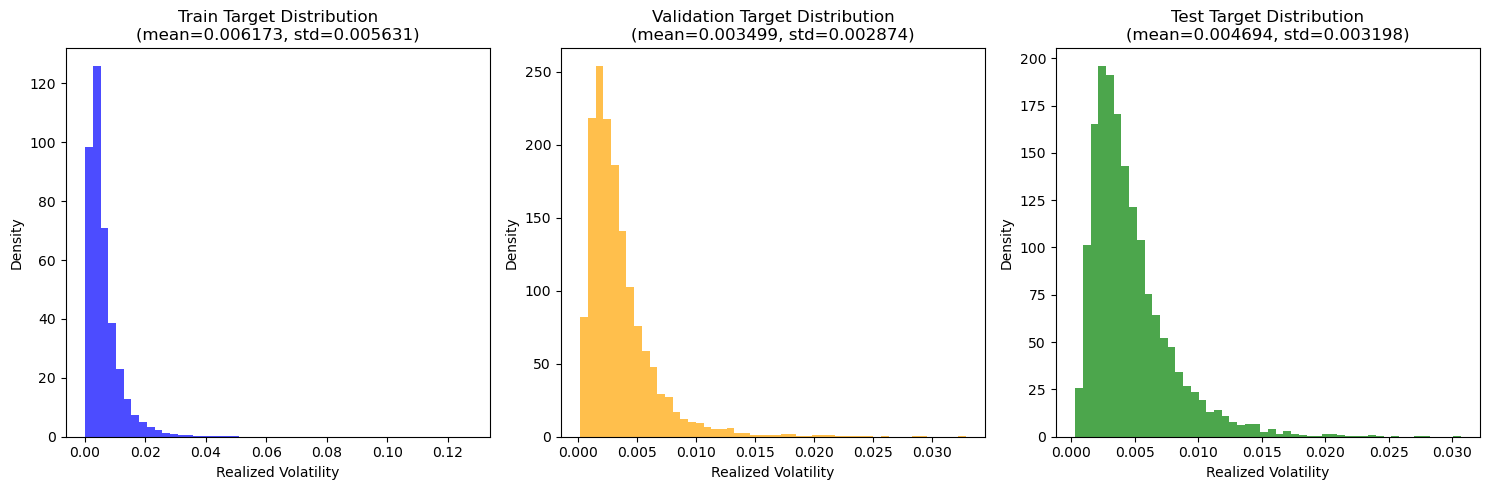

In [11]:
# 1. Train/Val/Test target distribution
example_key = "S42_W24_H6"
example_output = experiment_outputs[example_key]
meta = example_output["meta"]
window_len = meta["window_len"]
horizon = meta["horizon"]
target_col = meta["target_col"]

# Recreate the data splits to get target distributions
# The window offset is removed so plotted targets match supervised samples.
df_feat, feature_cols, target_col_check, rv_feature_col = engineer_features_volatility(df, horizon=horizon)
n = len(df_feat)
train_end = int(n * TRAIN_RATIO)
val_end = int(n * (TRAIN_RATIO + VAL_RATIO))

train_df = df_feat.iloc[:train_end].copy()
val_df = df_feat.iloc[train_end:val_end].copy()
test_df = df_feat.iloc[val_end:].copy()

# Get target values (accounting for window offset)
train_targets = train_df[target_col].iloc[window_len-1:].values
val_targets = val_df[target_col].iloc[window_len-1:].values  
test_targets = test_df[target_col].iloc[window_len-1:].values

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(train_targets, bins=50, alpha=0.7, color='blue', density=True)
plt.title(f'Train Target Distribution\n(mean={train_targets.mean():.6f}, std={train_targets.std():.6f})')
plt.xlabel('Realized Volatility')
plt.ylabel('Density')

plt.subplot(1, 3, 2)
plt.hist(val_targets, bins=50, alpha=0.7, color='orange', density=True)
plt.title(f'Validation Target Distribution\n(mean={val_targets.mean():.6f}, std={val_targets.std():.6f})')
plt.xlabel('Realized Volatility')
plt.ylabel('Density')

plt.subplot(1, 3, 3)
plt.hist(test_targets, bins=50, alpha=0.7, color='green', density=True)
plt.title(f'Test Target Distribution\n(mean={test_targets.mean():.6f}, std={test_targets.std():.6f})')
plt.xlabel('Realized Volatility')
plt.ylabel('Density')

plt.tight_layout()
plt.show()

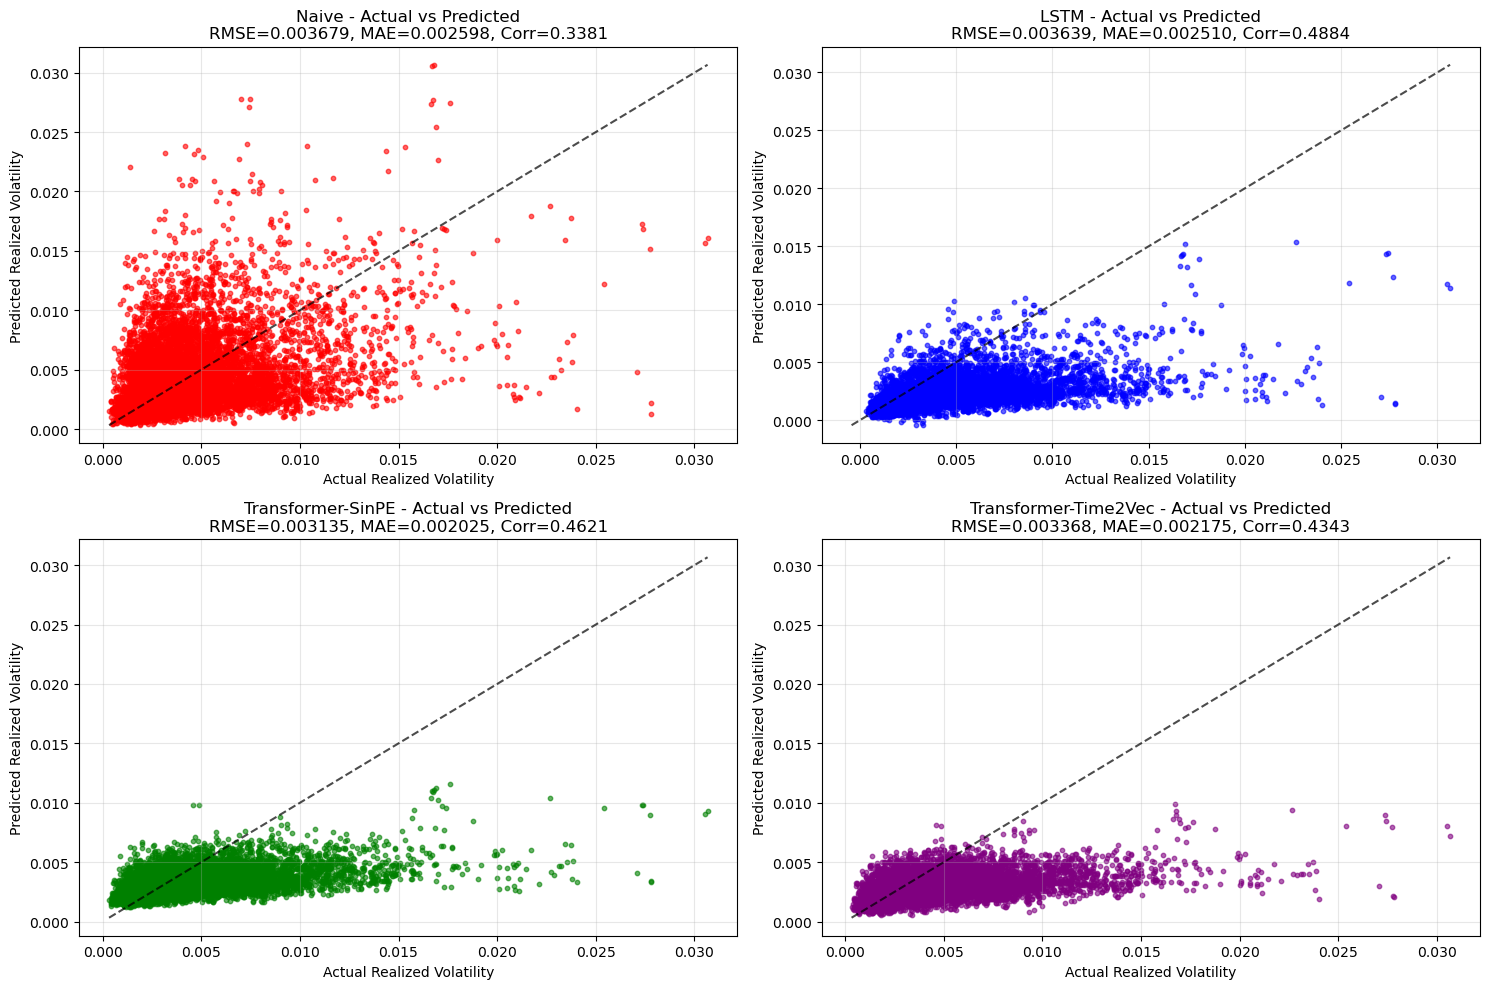

In [12]:
# 3. Actual vs Predicted on test set
example_key = "S42_W24_H6"
example_output = experiment_outputs[example_key]
predictions = example_output["predictions"]

plt.figure(figsize=(15, 10))

model_names = ["Naive", "LSTM", "Transformer-SinPE", "Transformer-Time2Vec"]
colors = ['red', 'blue', 'green', 'purple']

for i, (model_name, color) in enumerate(zip(model_names, colors)):
    # Compare each model's predictions against the ideal y=x diagonal.
    plt.subplot(2, 2, i+1)
    true_y, pred_y = predictions[model_name]
    
    plt.scatter(true_y, pred_y, alpha=0.6, color=color, s=10)
    
    # Add diagonal line
    min_val = min(true_y.min(), pred_y.min())
    max_val = max(true_y.max(), pred_y.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.7)
    
    # Calculate metrics for title
    mae = mean_absolute_error(true_y, pred_y)
    rmse = np.sqrt(mean_squared_error(true_y, pred_y))
    corr = np.corrcoef(true_y, pred_y)[0, 1]
    
    plt.title(f'{model_name} - Actual vs Predicted\nRMSE={rmse:.6f}, MAE={mae:.6f}, Corr={corr:.4f}')
    plt.xlabel('Actual Realized Volatility')
    plt.ylabel('Predicted Realized Volatility')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
# Export the aggregated summary so it can be reused outside the notebook.
summary_path = "btc_rv_window_horizon_results.csv"
summary_mean_std.to_csv(summary_path, index=False)
print(f"Saved summary results (mean ± std across 5 seeds) to {summary_path}")

Saved summary results (mean ± std across 5 seeds) to btc_rv_window_horizon_results.csv
